In [255]:
# SimPEG functionality
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.utils import model_builder
from simpeg.utils.io_utils.io_utils_electromagnetics import write_dcip2d_ubc
from simpeg import maps, data
from simpeg.electromagnetics.static.utils.static_utils import (
    generate_dcip_sources_line,
    pseudo_locations,
    plot_pseudosection,
    apparent_resistivity_from_voltage,
)
# SimPEG inversion machinery
from simpeg import (
    maps,
    data_misfit, 
    regularization, 
    optimization, 
    inverse_problem, 
    inversion, 
    directives
) 

# added these myself
from simpeg.electromagnetics.static.utils import generate_survey_from_abmn_locations
from pymatsolver import Pardiso as Solver 
from simpeg.data import Data

# discretize functionality
from discretize import TreeMesh
from discretize import TensorMesh
from discretize.utils import active_from_xyz

# Common Python functionality
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mpl.rcParams.update({"font.size": 14})  # default font size

# import project_utils.py
import project_utils as pu
print(pu.__file__)

write_output = False  # Optional

/home/krista/eosc-454-project-2026/project_utils.py


## Data Processing

In [256]:
# load the data file
dc_data_file = f"DATA/B8_2015_7_20150603_160m.dat"

# open and read each line of file
with open(dc_data_file) as f:
    print(f.read())


Project59 ZF20-4A 030615
2.00
11
1
Type of measurement (0=app.resistivity,1=resistance)
1
345
2
0
4 0.00 0.00 12.00 0.00 4.00 0.00 8.00 0.00 36.1133
4 4.00 0.00 16.00 0.00 8.00 0.00 12.00 0.00 74.0034
4 0.00 0.00 24.00 0.00 8.00 0.00 16.00 0.00 44.1974
4 8.00 0.00 20.00 0.00 12.00 0.00 16.00 0.00 49.2268
4 4.00 0.00 28.00 0.00 12.00 0.00 20.00 0.00 33.3716
4 0.00 0.00 36.00 0.00 12.00 0.00 24.00 0.00 30.7894
4 12.00 0.00 24.00 0.00 16.00 0.00 20.00 0.00 40.5875
4 8.00 0.00 32.00 0.00 16.00 0.00 24.00 0.00 43.8442
4 16.00 0.00 28.00 0.00 20.00 0.00 24.00 0.00 73.5224
4 4.00 0.00 40.00 0.00 16.00 0.00 28.00 0.00 30.0827
4 12.00 0.00 36.00 0.00 20.00 0.00 28.00 0.00 65.8646
4 0.00 0.00 48.00 0.00 16.00 0.00 32.00 0.00 18.1712
4 20.00 0.00 32.00 0.00 24.00 0.00 28.00 0.00 84.7208
4 8.00 0.00 44.00 0.00 20.00 0.00 32.00 0.00 27.8484
4 16.00 0.00 40.00 0.00 24.00 0.00 32.00 0.00 52.0927
4 4.00 0.00 52.00 0.00 20.00 0.00 36.00 0.00 20.9748
4 24.00 0.00 36.00 0.00 28.00 0.00 32.00 0.00 82.5351

### Read in data file into python dictionary

In [257]:
def read_dc_data(filename, verbose=True):
    """
    Read .dat dataset into a python dictionary.

    Input Data Description
    ----------------------
    At line 10+: Each line consists of coordinates for A, B, M, and N, respectively. Last column contains resistivity.

    Parameters
    ----------
    filename: str
        Path to the file to be parsed

    verbose: bool
        Print some things?

    Returns
    -------
    dict
        A dictionary with the locations of 
        - a_locations: the positive source electrode locations (numpy array) 
        - b_locations: the negative source electrode locations (numpy array) 
        - m_locations: the receiver locations (numpy array)
        - n_locations: the receiver locations (numpy array)
        - resistivity_data: the resistivity values per electrode orientation / row (numpy array)
        - n_sources: number of sources (int)
        - topo: coordinates defining topography (numpy array)

    """
    # read in the text file as a numpy array of strings (each row is an entry)
    contents = np.genfromtxt(filename, delimiter=' \n', dtype=str)

    # number of sources on line 7
    n_sources = int(contents[6].split()[0]) - 1
    
    if verbose is True: 
        print(f"number of sources: {n_sources}")
    
    # initialize storage for the electrode locations and data
    random_num = np.zeros(n_sources) # the number 4 at the start of each row
    # initialize as 2D arrays to account for coordinates
    a_locations = np.zeros((n_sources, 2))
    b_locations = np.zeros((n_sources, 2))
    m_locations = np.zeros((n_sources, 2))
    n_locations = np.zeros((n_sources, 2))
    resistivity_data = np.zeros(n_sources)
    
    # index to track where we have read in resistivity content 
    # start at line 10
    content_index = 9

    # loop over sources 
    for i in range(n_sources):
        # start by reading in the source info 
        content_index = content_index + 1  # read the next line
        random_num, Ax, Ay, Bx, By, Mx, My, Nx, Ny, resistivity = contents[content_index].split()  # this is a string

        a_location = [float(Ax), float(Ay)]
        b_location = [float(Bx), float(By)]
        m_location = [float(Mx), float(My)]
        n_location = [float(Nx), float(Ny)]

        # convert the strings to a float for locations
        a_locations[i, :] = a_location
        b_locations[i, :] = b_location
        m_locations[i, :] = m_location
        n_locations[i, :] = n_location
        resistivity_data[i] = float(resistivity)

        if verbose is True: 
            print(f"Source {i}: A-loc: {a_location}, B-loc: {b_location}, M-loc: {m_location}, N-loc: {n_location}, Resistivity: {resistivity}")

    # create topography array (only 2 coordinates given since it's flat)
    topo = np.zeros((2, 2))
    content_index = 357 
    for i in range(2):
        x, z = contents[content_index].split()
        xz = [float(x), float(z)]
        topo[i, :] = xz
        content_index = content_index + 1

    if verbose is True: 
        print(f"Topography defined by: {topo}")

    return {
        "a_locations": a_locations,
        "b_locations": b_locations, 
        "m_locations": m_locations,
        "n_locations": n_locations,
        "resistivity_data": resistivity_data, 
        "n_sources": n_sources,
        "topography": topo,
    }

In [258]:
dc_data_dict = read_dc_data(dc_data_file)

number of sources: 344
Source 0: A-loc: [4.0, 0.0], B-loc: [16.0, 0.0], M-loc: [8.0, 0.0], N-loc: [12.0, 0.0], Resistivity: 74.0034
Source 1: A-loc: [0.0, 0.0], B-loc: [24.0, 0.0], M-loc: [8.0, 0.0], N-loc: [16.0, 0.0], Resistivity: 44.1974
Source 2: A-loc: [8.0, 0.0], B-loc: [20.0, 0.0], M-loc: [12.0, 0.0], N-loc: [16.0, 0.0], Resistivity: 49.2268
Source 3: A-loc: [4.0, 0.0], B-loc: [28.0, 0.0], M-loc: [12.0, 0.0], N-loc: [20.0, 0.0], Resistivity: 33.3716
Source 4: A-loc: [0.0, 0.0], B-loc: [36.0, 0.0], M-loc: [12.0, 0.0], N-loc: [24.0, 0.0], Resistivity: 30.7894
Source 5: A-loc: [12.0, 0.0], B-loc: [24.0, 0.0], M-loc: [16.0, 0.0], N-loc: [20.0, 0.0], Resistivity: 40.5875
Source 6: A-loc: [8.0, 0.0], B-loc: [32.0, 0.0], M-loc: [16.0, 0.0], N-loc: [24.0, 0.0], Resistivity: 43.8442
Source 7: A-loc: [16.0, 0.0], B-loc: [28.0, 0.0], M-loc: [20.0, 0.0], N-loc: [24.0, 0.0], Resistivity: 73.5224
Source 8: A-loc: [4.0, 0.0], B-loc: [40.0, 0.0], M-loc: [16.0, 0.0], N-loc: [28.0, 0.0], Resistiv

In [259]:
for key, value in dc_data_dict.items():
    print(f"{key:<20}: {type(value)}")

a_locations         : <class 'numpy.ndarray'>
b_locations         : <class 'numpy.ndarray'>
m_locations         : <class 'numpy.ndarray'>
n_locations         : <class 'numpy.ndarray'>
resistivity_data    : <class 'numpy.ndarray'>
n_sources           : <class 'int'>
topography          : <class 'numpy.ndarray'>


### Create SimPEG Survey
The data gives the ABMN electrode locations, meaning I can use the generate_survey_from_abmn_locations to define the survey

In [260]:
# get location arrays from dictionary
a_loc = dc_data_dict["a_locations"]
b_loc = dc_data_dict["b_locations"]
m_loc = dc_data_dict["m_locations"]
n_loc = dc_data_dict["n_locations"]

survey = generate_survey_from_abmn_locations(locations_a=a_loc, locations_b=b_loc, locations_m=m_loc, locations_n=n_loc, data_type="volt")

resist_data = dc_data_dict["resistivity_data"]

dc_data = Data(
    survey=survey, 
    dobs=np.hstack(resist_data)
)

### Create a Pseudosection

/tmp/ipykernel_605825/2019531964.py:14: UserWarning: plot_pseudosection unused kwargs: ['data_location']
  plot_pseudosection(


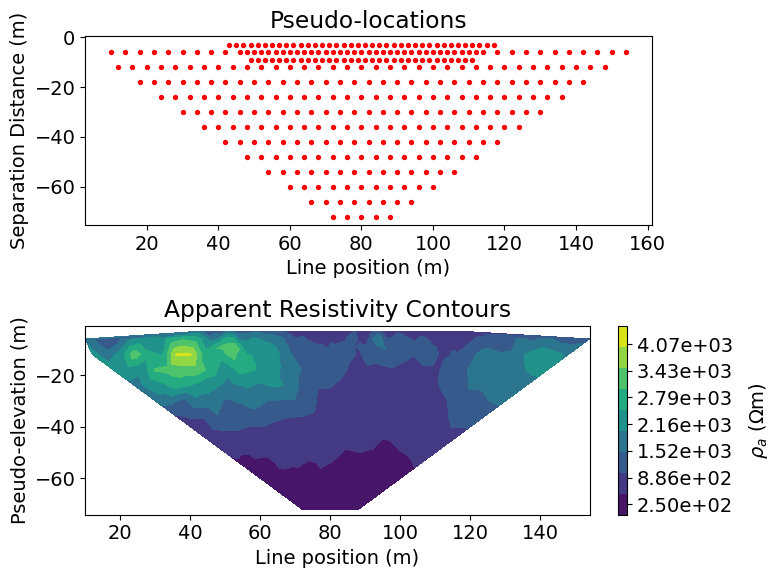

In [261]:
# Survey used Wenner configuration, so I will keep the default wenner_tolerance
pseudo_locations_xz = pseudo_locations(survey)
# print(len(pseudo_locations_xz))

# Plot pseudo-section
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

ax[0].scatter(pseudo_locations_xz[:, 0], pseudo_locations_xz[:, -1], 8, "r") # access pseudo_locations_xz depths [midxy, depth]
ax[0].set_xlabel("Line position (m)")
ax[0].set_ylabel("Separation Distance (m)")
ax[0].set_title("Pseudo-locations")

# Plot pseudosections of the apparent resistivity 
plot_pseudosection(
    data=dc_data,
    data_type="apparent_resistivity",
    plot_type="contourf",
    cbar_label=r'$\rho_a$ (Ωm)',
    data_location=True,
    ax=ax[1]
)

ax[1].set_title("Apparent Resistivity Contours")

plt.tight_layout()
plt.show()


Data appears to be concentrated more shallowly. Therefore, my confidence with depth the inversion with decrease. 

### Histogram of Data

4066.366926305432


np.float64(1065.1676672702315)

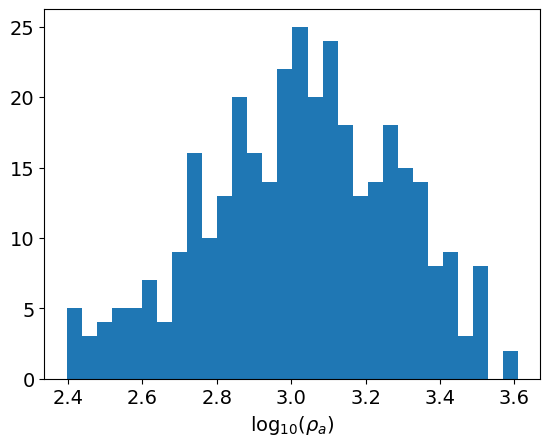

In [262]:
# calculate apparent resistivity
apparent_resistivity = apparent_resistivity_from_voltage(survey=survey, volts=resist_data, space_type="half space")

print(apparent_resistivity.max())
fig, ax = plt.subplots(1, 1)
out = ax.hist(np.log10(apparent_resistivity), bins=30)
ax.set_xlabel("log$_{10}(\\rho_a)$")

## Estimate a background model
# rho0 = 10**np.mean(np.log10(apparent_resistivity))
rho0 = np.median(apparent_resistivity)
rho0

## Setting Up Forward Problem

### Assign Uncertainites to Data
$\text{standard\_deviation} = \text{percent\_error} \times |d^{obs}| + \text{noise\_floor}$

In [ ]:
dc_data.standard_deviation = 1e-6 + 0.06 * np.abs(dc_data.dobs)

### Designing a Mesh

We will use a base mesh with 0.5 m x 0.5 m cells
The x core domain is between 0.0 m and 160.0 m
The z core domain extent is -30.0 m


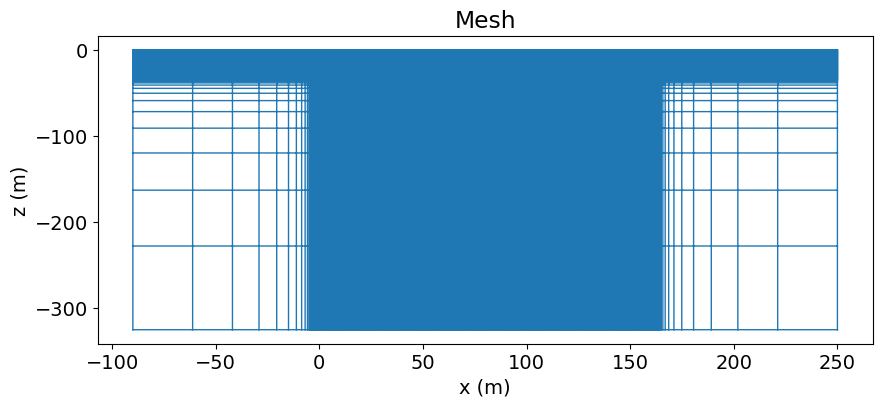

In [264]:
min_electrode_spacing = 2
n_cells_per_spacing = 4

dx = min_electrode_spacing / n_cells_per_spacing
dz = min_electrode_spacing / n_cells_per_spacing


print(f"We will use a base mesh with {dx} m x {dz} m cells")

core_domain_x = np.r_[
    survey.unique_electrode_locations[:, 0].min(),
    survey.unique_electrode_locations[:, 0].max()
]

print(f"The x core domain is between {core_domain_x[0]} m and {core_domain_x[1]} m")

# depth of investigation already given by data source (24 m) --> but, make it 30 m 
core_domain_z = np.r_[-30, 0.]
print(f"The z core domain extent is {core_domain_z[0]} m")

# increase mesh extents
n_core_extra = 10 # number of extra cells with same resolution as core domain
n_core_x = np.ceil(np.diff(core_domain_x)/dx) + n_core_extra*2  # on each side
n_core_z = np.ceil(np.diff(core_domain_z)/dz) + n_core_extra  # just below

padding_factor = 1.5
n_pad_x = 10
n_pad_z = 13 # 13

hx = [(dx, n_pad_x, -padding_factor), (dx, n_core_x), (dx, n_pad_x, padding_factor)]
hz = [(dz, n_pad_z, -padding_factor), (dz, n_core_z)]

mesh = TensorMesh([hx, hz])

# origin of the mesh
mesh.x0 = np.r_[
    -mesh.h[0][:n_pad_x + n_core_extra].sum() + core_domain_x.min(),
    -mesh.h[1].sum()
]

mesh 

# Plot mesh
fig, ax1 = plt.subplots(figsize=(10, 4))
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

plt.show()

### Define the Model

In [265]:
# Define model for following case: the model consists of the log-resistivity values for all active cells

# Get topo array from dictionary
topo_2d = dc_data_dict["topography"]

# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_2d)

# Number of active cells
num_active_cells = np.sum(active_cells)

### Define the Forward Simulation

In [266]:
# Use Simulation2DNodel
# To fully define the forward simulation, we need to connect the simulation object to the survey, mesh and mapping from the model to the mesh

# Use Exponential Map: m = log(rho)
mapping = maps.ExpMap(mesh)

# Generate 2.5D DC problem
simulation_dc = dc.Simulation2DNodal(
    mesh, 
    rhoMap=mapping, 
    solver=Solver, 
    survey=dc_data.survey,
    bc_type="Neumann",
    storeJ=True, # runs faster --> can use for smaller models

)


In [267]:
%time # prints CPU time and wall (real) time to see how "taxing" simulation was

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 19.3 μs


### Validate Forward Simulation

1) Run a simulation over a half-space and see if the apparent resistivites computed from simulated data equal the true halfspace resistivity $\rho_0$.
2) Plot the percent error in the apparent resistivity and see if the error is less than the errors in data. If error is greater than 5%, check:
    - Boundary conditions - does the mesh extend far enough?
    - Discretization near source and receivers - is the cell resolution high enough near the electrodes?
    - Are we using enough filters?

In [268]:
# To check our mesh and forward simulation, we run a simulation over a half-space. 
# The apparent resistivities we compute from the simulated data should be equal to the true half-space resistivity.

# run the forward simulation over the half-space & plot apparent resistivities
num_mesh_cells = mesh.nC
halfspace_model = np.ones(num_mesh_cells) * np.log(rho0) # defines model for log-resistivity space
synthetic_data = simulation_dc.make_synthetic_data(halfspace_model) # gives data that would be measured if earth had model "halfspace_model"

Text(0.5, 0, 'x (m)')

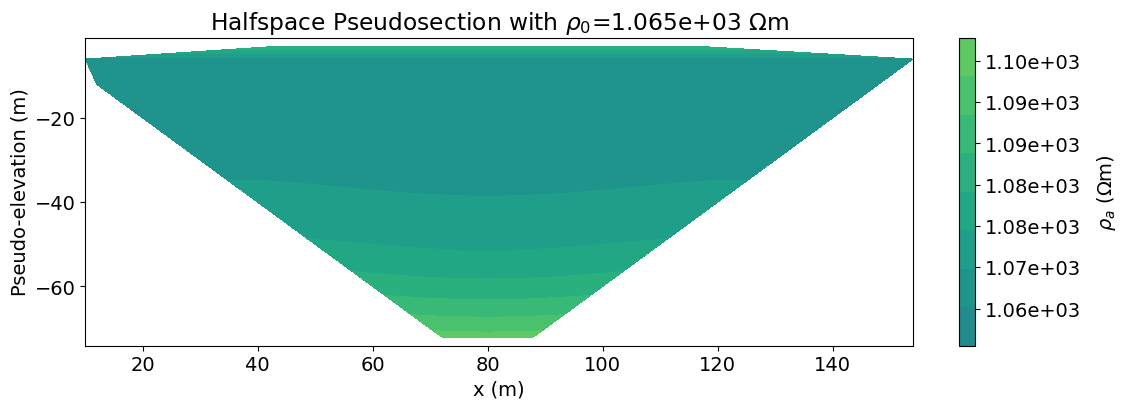

In [269]:
# plot halfspace psuedosection
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# clim = np.r_[apparent_resistivity.min(), apparent_resistivity.max()]
min_rho = rho0 - 0.06 * rho0 
max_rho = rho0 + 0.06 * rho0 
clim = np.r_[min_rho, max_rho]
plot_pseudosection(
    synthetic_data, 
    data_type="apparent resistivity", 
    clim=clim,
    plot_type="contourf", 
    cbar_label=r'$\rho_a$ (Ωm)',
    ax=ax,
)

ax.set_title(rf"Halfspace Pseudosection with $\rho_0$={rho0:.3e} $\Omega$m")
ax.set_xlabel("x (m)")

The above looks like a halfspace (minimal variation in apparent resistivities).

(<Axes: xlabel='Line position (m)', ylabel='Pseudo-elevation (m)'>,
 <matplotlib.tri._tricontour.TriContourSet at 0x7f8c634f6b90>)

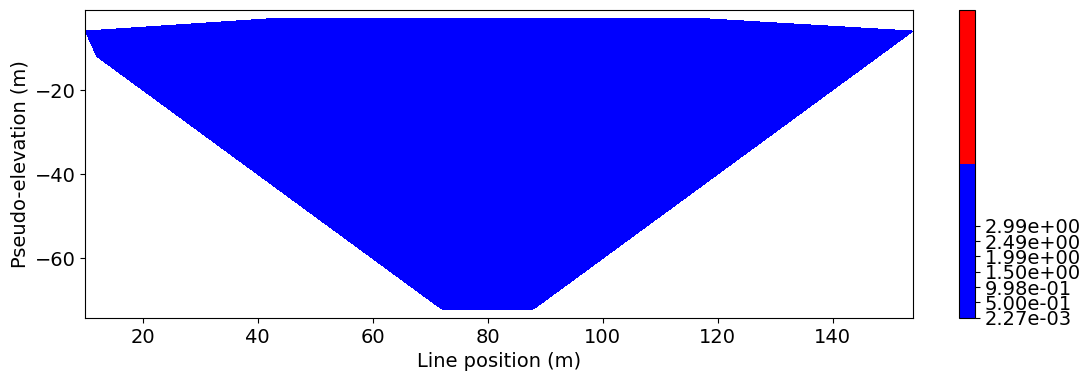

In [270]:
# Plot percent error
app_resistivity_halfspace_model = apparent_resistivity_from_voltage(synthetic_data.survey, synthetic_data.dobs)
percent_error = (app_resistivity_halfspace_model - rho0) / rho0 * 100
abs_error = np.abs(percent_error)

# define 2 colours for plot: less than 5% and greater than 5%
contourf_opts={"levels": [0, 5, 50], 
               "colors": ["blue", "red"]
                }

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

plot_pseudosection(
    data=synthetic_data.survey,
    dobs=abs_error,
    data_type="apparent_resistivity",
    plot_type="contourf",
    contourf_opts=contourf_opts,
    ax=ax
)

Most errors are less than 5%

## DC Resistivity Inversion

### Choose Data Misfit

In [271]:
# Set up the data misfit, phid
# Use least-squares data misfit
phid_misfit = data_misfit.L2DataMisfit(data=dc_data, simulation=simulation_dc, debug=True)

### Choose Regularization

In [ ]:
# Define alpha weights
alph_s = 0.06
alph_x = 1
alph_y = 0.75
reg = regularization.WeightedLeastSquares(
    mesh,
    reference_model=halfspace_model,
    alpha_s=alph_s, # scaling constant for the smallness regularization term --> use to scale the smallness tern based on cell size, not mesh
    alpha_x=alph_x,
    alpha_y=alph_y,  # since this is a 2D problem, the second dimension is "y" 
)
# alpha_s=1./mesh.h[0].min()**2,
print(f"The length paramter for x = {np.sqrt(alph_x/alph_s)} m and for y = {np.sqrt(alph_y/alph_s)} m.")

The length paramter for x = 4.47213595499958 m and for y = 4.47213595499958 m.


### Choose Optimization Method 

In [273]:
opt = optimization.InexactGaussNewton(maxIter=20, maxIterCG=30)
inv_prob = inverse_problem.BaseInvProblem(phid_misfit, reg, opt)

/home/krista/miniconda3/envs/eosc-454/lib/python3.11/site-packages/simpeg/optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val


### Assemble & Run Inversion

In [274]:
# directives
sensitivity = directives.UpdateSensitivityWeights(every_iteration=True, threshold_value=1e-4) # threshold value for DC resisitvity usually b/w 1e-5 and 1e-3

beta_estimate = directives.BetaEstimate_ByEig(beta0_ratio=10)
# Use 2 for weakly non-linear optimization problems. 
# Use 3 for general non-linear optimization problems.
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=2) # update beta

# save iterations
saved_output_dict = directives.SaveOutputDictEveryIteration()

# check betas
target = directives.TargetMisfit()

inv = inversion.BaseInversion(
    inv_prob, directiveList=[sensitivity, beta_estimate, beta_schedule, target, saved_output_dict]
)

In [275]:
# Run inversion
mopt = inv.run(halfspace_model) # set mref to halfspace model

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0


INFO: Directive TargetMisfit: Target data misfit is 344.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  9.28e+02  9.42e+04  0.00e+00  9.42e+04                                 
   1  9.28e+02  1.47e+04  3.70e+00  1.81e+04    3.02e+03      0              
   2  9.28e+02  4.26e+03  4.88e+00  8.79e+03    1.18e+03      0   Skip BFGS  
   3  4.64e+02  1.90e+03  6.07e+00  4.72e+03    3.36e+02      0              
   4  4.64e+02  1.82e+03  5.58e+00  4.41e+03    1.27e+02      0              
   5  2.32e+02  1.06e+03  7.88e+00  2.89e+03    1.80e+02      0              
   6  2.32e+02  1.04e+03  7.34e+00  2.75e+03    6.07e+01      0              
   7  1.16e+02  6.33e+02  9.90e+00  1.78e+03    1.31e+02      0              
   8  1.16e+02  6.08e+02  9.49e+00  1.71e+03    5.59e+01      0              
   9  5.80e+01  3.71e+02  1.25e+01  1.10e+03    9.64e+01      0

### Choose to view plots for last iterated model or another one

In [280]:
# Get saved iterations
# Get dictionary of each iteration input
iterations_dict = saved_output_dict.outDict
# print(iterations_dict)

# Choose if you want to view misfit for last iterated model or previous
last_iteration = False
iteration = 9 # set what iteration you want to see 

if(last_iteration==True):
    # Get predicted data from recovered model
    dpred = inv_prob.dpred
    dobs = dc_data.dobs
    std = dc_data.standard_deviation

    rho = (mapping*mopt) # converts from log model to physical resistivity (Ω·m)
else:
    dpred = iterations_dict[iteration]["dpred"]
    dobs = dc_data.dobs
    std = dc_data.standard_deviation

    # To view on of the previous iterated models
    m_selected = iterations_dict[iteration]["m"]
    rho = mapping * m_selected

/tmp/ipykernel_605825/1861070716.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


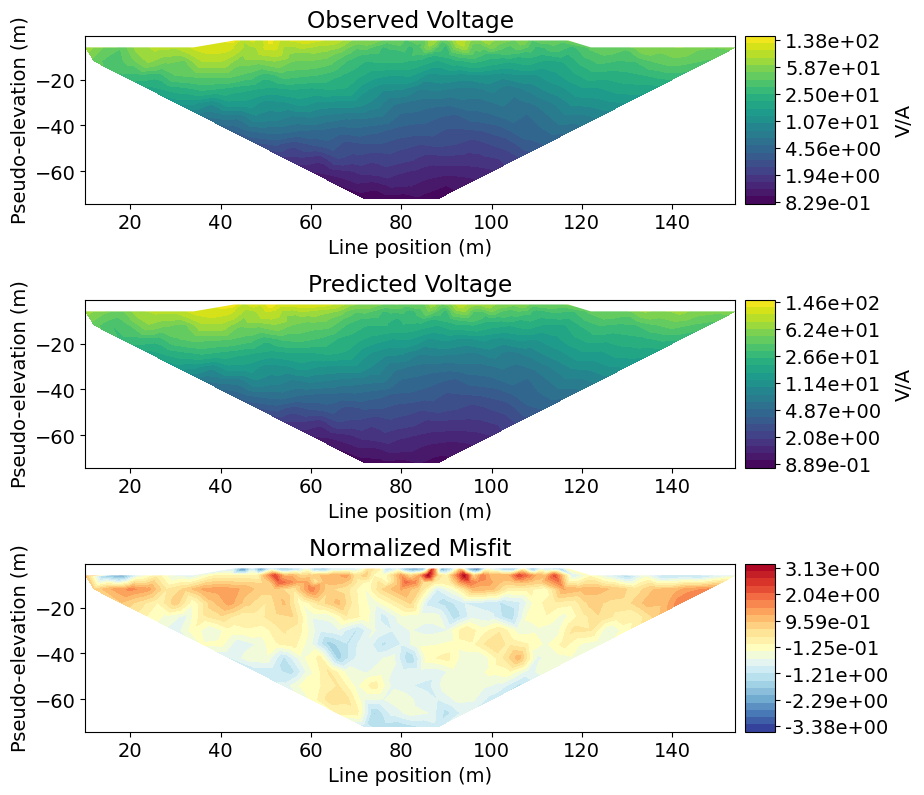

In [281]:
# Plot pseudosection
fig = plt.figure(figsize=(10, 8))

data_array = [np.abs(dobs), np.abs(dpred), (dobs - dpred) / std]
plot_title = ["Observed Voltage", "Predicted Voltage", "Normalized Misfit"]
plot_units = ["V/A", "V/A", ""]
scale = ["log", "log", "linear"]
cmap_list = [mpl.cm.viridis, mpl.cm.viridis, mpl.cm.RdYlBu_r] # change plot colour

ax1 = 3 * [None]
cax1 = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.15, 0.72 - 0.33 * ii, 0.65, 0.21])
    cax1[ii] = fig.add_axes([0.81, 0.72 - 0.33 * ii, 0.03, 0.21])
    cplot[ii] = plot_pseudosection(
        dc_data.survey,
        data_array[ii],
        "contourf",
        ax=ax1[ii],
        cax=cax1[ii],
        scale=scale[ii],
        cbar_label=plot_units[ii],
        mask_topography=True,
        contourf_opts={"levels": 25, "cmap": cmap_list[ii]},
    )
    ax1[ii].set_title(plot_title[ii])

plt.tight_layout()
plt.show()

### Show Subsurface Resisitivity Model

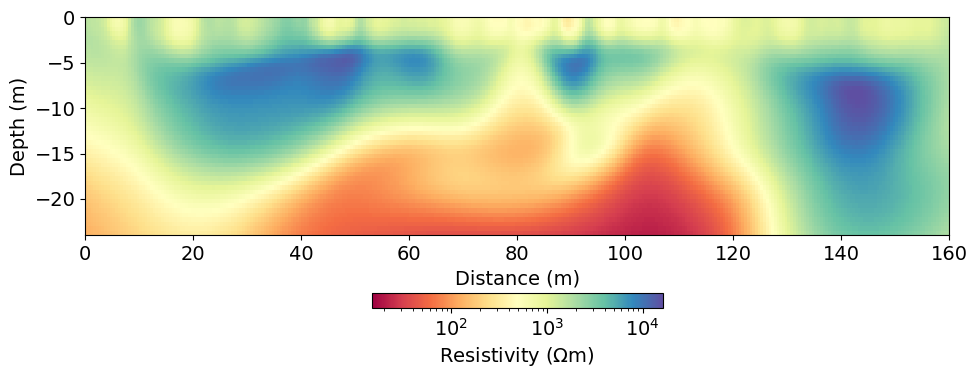

In [282]:
fig, ax = plt.subplots(figsize=(10, 4))

out = mesh.plot_image(
    rho, 
    pcolor_opts={'norm':LogNorm(), 'cmap':'Spectral'}, # puts resistivity on log scale and uses a spectral colour map
    ax=ax,
)                  

ax.set_xlim((0, 160))
ax.set_ylim((-24, 0))                           
cb = plt.colorbar(out[0], fraction=0.05, orientation='horizontal', ax=ax, pad=0.2)
cb.set_label("Resistivity ($\Omega$m)")
# ax.set_title("Smoothest")                                     
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Depth (m)')
plt.tight_layout()

### Plot Tikhonov Curves

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


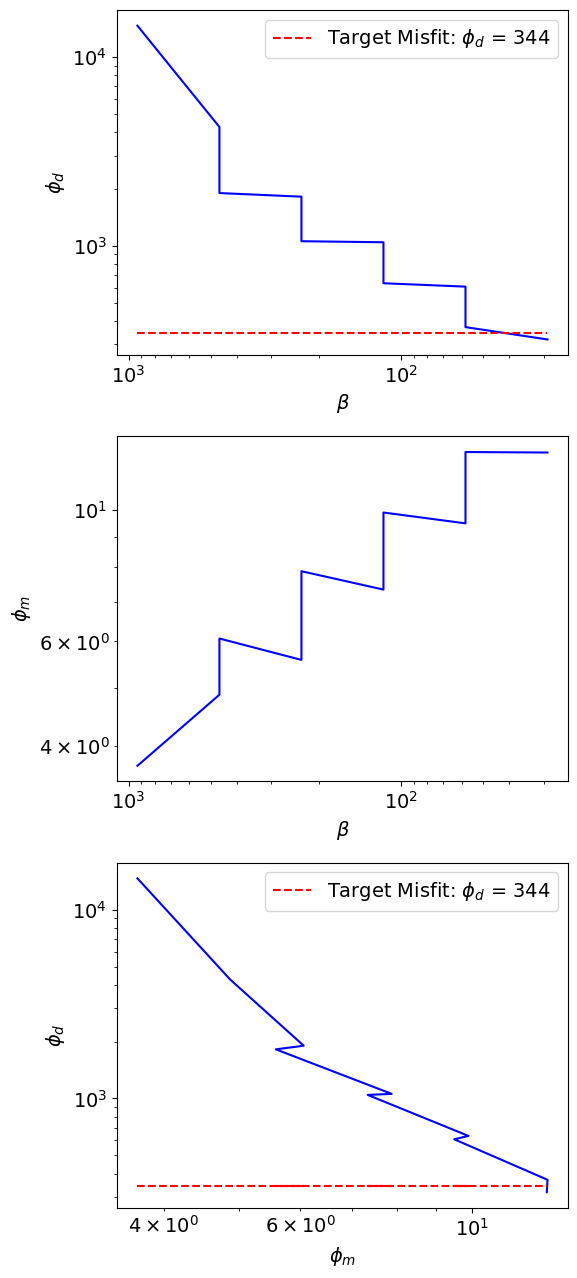

In [279]:
pu.plot_tikhonov_curves(dictionary=iterations_dict, target=target)